In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from scipy.stats import beta as beta_dist

In [2]:
# Constants and config
load_dotenv(Path("..") / ".env")
sys.path.insert(0, str(Path(".")))

DATA_DIR = Path("..") / "data" / "synthetic"
if not DATA_DIR.exists():
    DATA_DIR = Path("data") / "synthetic"
SEED = 42
N_DRAWS = 200_000
N_ARPU_DRAWS = 50_000
ABSOLUTE_LIFT = 0.025
MIN_PRACTICAL_LIFT = 0.010
ROPE = 0.005

rng = np.random.default_rng(SEED)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Bayesian Experimentation

This notebook shows a pragmatic Bayesian workflow for a product experiment using the synthetic SaaS data.

| Part | Topic |
|------|-------|
| 1 | Simulate a randomized experiment from the synthetic user mix |
| 2 | Estimate conversion with a Beta-Binomial posterior |
| 3 | Make a launch decision using probability, practical lift, and expected loss |
| 4 | Monitor the posterior as data arrives |
| 5 | Estimate ARPU lift with a Bayesian bootstrap |

Bayesian experimentation is useful when stakeholders ask decision questions directly: how likely is the variant better, how likely is the lift worth shipping, and what is the cost of being wrong?

## Part 1 - Build a Synthetic Experiment

The source data is observational, so this notebook creates a reproducible randomized experiment on top of it. The baseline conversion probability comes from each acquisition channel's historical synthetic conversion rate, then the treatment adds a known absolute lift.

In [3]:
users = pd.read_csv(DATA_DIR / "users.csv", parse_dates=["signup_at", "churn_at"])
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["billed_at", "period_start", "period_end"])

experiment = users[["user_id", "signup_at", "acquisition_channel", "country"]].copy()
experiment["variant"] = np.where(rng.random(len(experiment)) < 0.5, "control", "treatment")

channel_rates = users.groupby("acquisition_channel")["converted"].mean()
experiment["base_conversion_prob"] = experiment["acquisition_channel"].map(channel_rates)
experiment["true_conversion_prob"] = np.where(
    experiment["variant"].eq("treatment"),
    np.minimum(experiment["base_conversion_prob"] + ABSOLUTE_LIFT, 0.95),
    experiment["base_conversion_prob"],
)
experiment["converted_in_experiment"] = rng.binomial(
    1,
    experiment["true_conversion_prob"].to_numpy(),
).astype(bool)

orders_with_signup = orders.merge(users[["user_id", "signup_at"]], on="user_id", how="left")
orders_with_signup["days_since_signup"] = (
    orders_with_signup["billed_at"] - orders_with_signup["signup_at"]
).dt.days
first_30d_revenue = (
    orders_with_signup.query("0 <= days_since_signup <= 30")
    .groupby("user_id")["amount_usd"]
    .sum()
    .rename("first_30d_revenue")
)
revenue_pool = first_30d_revenue[first_30d_revenue > 0].to_numpy()
if len(revenue_pool) == 0:
    raise ValueError("Synthetic orders must include positive revenue rows.")

experiment["first_30d_revenue"] = 0.0
converted_mask = experiment["converted_in_experiment"]
experiment.loc[converted_mask, "first_30d_revenue"] = rng.choice(
    revenue_pool,
    size=int(converted_mask.sum()),
    replace=True,
)
experiment.loc[
    converted_mask & experiment["variant"].eq("treatment"),
    "first_30d_revenue",
] *= 1.05

summary = (
    experiment.groupby("variant")
    .agg(
        n=("user_id", "size"),
        conversions=("converted_in_experiment", "sum"),
        conversion_rate=("converted_in_experiment", "mean"),
        arpu=("first_30d_revenue", "mean"),
    )
    .reindex(["control", "treatment"])
)
summary["conversions"] = summary["conversions"].astype(int)
summary.style.format({"conversion_rate": "{:.2%}", "arpu": "${:,.2f}"})

,n,conversions,conversion_rate,arpu
variant,,,,
control,2545,557,21.89%,$52.62
treatment,2455,637,25.95%,$64.13


## Part 2 - Beta-Binomial Conversion Model

For binary conversion, the Beta-Binomial model is the workhorse:

$$p_a \sim \operatorname{Beta}(\alpha, \beta)$$

$$x_a \sim \operatorname{Binomial}(n_a, p_a)$$

$$p_a \mid x_a, n_a \sim \operatorname{Beta}(\alpha + x_a, \beta + n_a - x_a)$$

The prior below is uniform, `Beta(1, 1)`. In production, use a weakly informative prior from historical experiments when you have enough comparable history.

In [4]:
ALPHA_PRIOR = 1
BETA_PRIOR = 1

posterior_params = {}
for arm in ["control", "treatment"]:
    n = int(summary.loc[arm, "n"])
    conversions = int(summary.loc[arm, "conversions"])
    posterior_params[arm] = {
        "alpha": ALPHA_PRIOR + conversions,
        "beta": BETA_PRIOR + n - conversions,
    }

control_draws = rng.beta(
    posterior_params["control"]["alpha"],
    posterior_params["control"]["beta"],
    size=N_DRAWS,
)
treatment_draws = rng.beta(
    posterior_params["treatment"]["alpha"],
    posterior_params["treatment"]["beta"],
    size=N_DRAWS,
)
lift_draws = treatment_draws - control_draws
relative_lift_draws = lift_draws / np.maximum(control_draws, 1e-12)

posterior_summary = pd.DataFrame(
    {
        "arm": ["control", "treatment"],
        "observed_rate": summary["conversion_rate"].to_numpy(),
        "posterior_mean": [control_draws.mean(), treatment_draws.mean()],
        "credible_interval_low": [np.quantile(control_draws, 0.025), np.quantile(treatment_draws, 0.025)],
        "credible_interval_high": [np.quantile(control_draws, 0.975), np.quantile(treatment_draws, 0.975)],
    }
)

decision_metrics = pd.Series(
    {
        "Pr(treatment > control)": (lift_draws > 0).mean(),
        "Pr(lift >= min practical lift)": (lift_draws >= MIN_PRACTICAL_LIFT).mean(),
        "Posterior mean lift": lift_draws.mean(),
        "95% CrI lift low": np.quantile(lift_draws, 0.025),
        "95% CrI lift high": np.quantile(lift_draws, 0.975),
        "Posterior mean relative lift": relative_lift_draws.mean(),
    }
)

display(posterior_summary.style.format({col: "{:.2%}" for col in posterior_summary.columns if col != "arm"}))
decision_metrics.to_frame("value").style.format("{:.2%}")

,arm,observed_rate,posterior_mean,credible_interval_low,credible_interval_high
0,control,21.89%,21.91%,20.32%,23.54%
1,treatment,25.95%,25.96%,24.24%,27.72%


,value
Pr(treatment > control),99.96%
Pr(lift >= min practical lift),99.44%
Posterior mean lift,4.06%
95% CrI lift low,1.69%
95% CrI lift high,6.43%
Posterior mean relative lift,18.69%


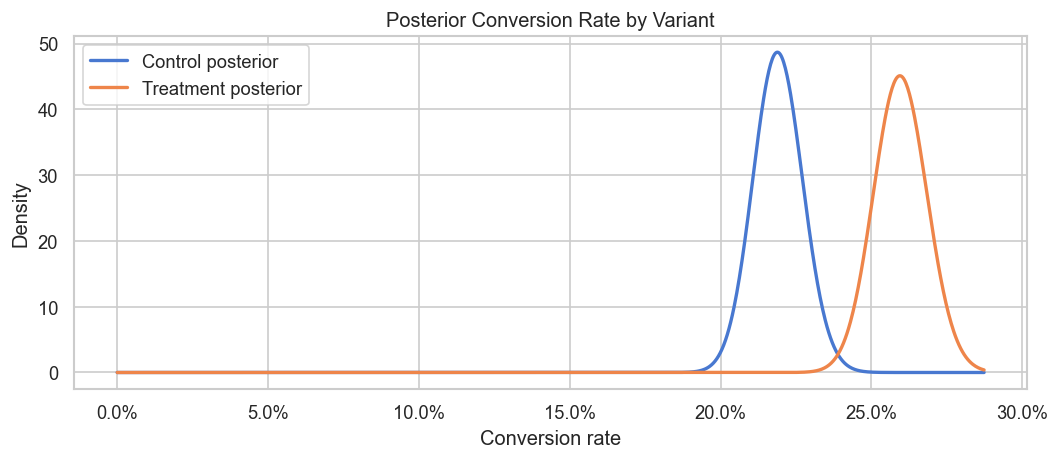

In [5]:
upper = max(np.quantile(control_draws, 0.999), np.quantile(treatment_draws, 0.999))
x = np.linspace(0, upper, 1_000)

fig, ax = plt.subplots(figsize=(9, 4))
for arm, color in [("control", "C0"), ("treatment", "C1")]:
    params = posterior_params[arm]
    ax.plot(
        x,
        beta_dist.pdf(x, params["alpha"], params["beta"]),
        label=f"{arm.title()} posterior",
        color=color,
        linewidth=2,
    )

ax.set_title("Posterior Conversion Rate by Variant")
ax.set_xlabel("Conversion rate")
ax.set_ylabel("Density")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.show()

## Part 3 - Decision Rules, Not Just Significance

A Bayesian result should end in a decision rule. A useful default is:

- Ship when `Pr(lift >= minimum practical lift)` is high enough.
- Do not ship when the posterior mass is mostly inside a region of practical equivalence.
- Continue when the expected loss of choosing now is still material.

The exact thresholds are product choices. They should be written before the experiment starts.

In [6]:
thresholds = np.arange(0, 0.051, 0.005)
decision_table = pd.DataFrame(
    {
        "minimum_lift": thresholds,
        "prob_lift_exceeds_threshold": [(lift_draws >= threshold).mean() for threshold in thresholds],
        "expected_shortfall_vs_threshold": [np.maximum(threshold - lift_draws, 0).mean() for threshold in thresholds],
    }
)

expected_loss_if_ship = np.maximum(control_draws - treatment_draws, 0).mean()
expected_loss_if_keep_control = np.maximum(treatment_draws - control_draws, 0).mean()
prob_practically_equivalent = (np.abs(lift_draws) <= ROPE).mean()

if (lift_draws >= MIN_PRACTICAL_LIFT).mean() >= 0.95:
    recommendation = "Ship treatment"
elif prob_practically_equivalent >= 0.80:
    recommendation = "Do not ship; effect is likely too small"
else:
    recommendation = "Keep running or decide with product risk tolerance"

print(f"Minimum practical lift: {MIN_PRACTICAL_LIFT:.1%}")
print(f"Region of practical equivalence: +/- {ROPE:.1%}")
print(f"Expected loss if ship treatment: {expected_loss_if_ship:.2%}")
print(f"Expected loss if keep control:  {expected_loss_if_keep_control:.2%}")
print(f"Posterior probability inside ROPE: {prob_practically_equivalent:.2%}")
print(f"Recommendation: {recommendation}")

decision_table.style.format(
    {
        "minimum_lift": "{:.1%}",
        "prob_lift_exceeds_threshold": "{:.1%}",
        "expected_shortfall_vs_threshold": "{:.2%}",
    }
)

Minimum practical lift: 1.0%
Region of practical equivalence: +/- 0.5%
Expected loss if ship treatment: 0.00%
Expected loss if keep control:  4.06%
Posterior probability inside ROPE: 0.14%
Recommendation: Ship treatment


,minimum_lift,prob_lift_exceeds_threshold,expected_shortfall_vs_threshold
0,0.0%,100.0%,0.00%
1,0.5%,99.8%,0.00%
2,1.0%,99.4%,0.00%
3,1.5%,98.3%,0.01%
4,2.0%,95.5%,0.02%
5,2.5%,90.0%,0.06%
6,3.0%,80.9%,0.13%
7,3.5%,67.8%,0.25%
8,4.0%,51.9%,0.45%
9,4.5%,35.7%,0.74%


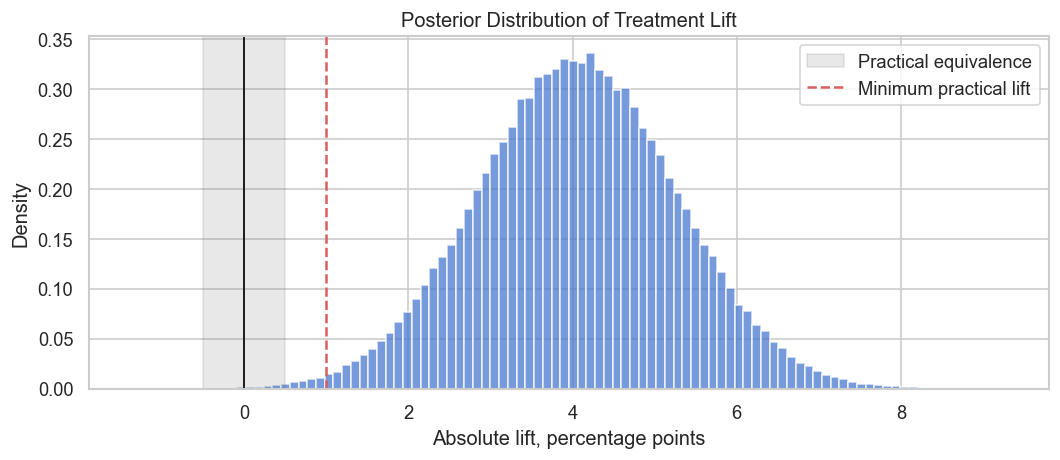

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lift_draws * 100, bins=100, density=True, alpha=0.75)
ax.axvspan(-ROPE * 100, ROPE * 100, color="gray", alpha=0.18, label="Practical equivalence")
ax.axvline(0, color="black", linewidth=1)
ax.axvline(MIN_PRACTICAL_LIFT * 100, color="C3", linestyle="--", label="Minimum practical lift")
ax.set_title("Posterior Distribution of Treatment Lift")
ax.set_xlabel("Absolute lift, percentage points")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

## Part 4 - Sequential Posterior Monitoring

Bayesian monitoring is not a license to improvise. The decision rule still needs to be fixed before launch. The advantage is that the quantity being monitored is directly decision-oriented: posterior probability and expected loss.

In [8]:
stream = experiment.sample(frac=1, random_state=SEED).reset_index(drop=True)
stream["look"] = pd.qcut(np.arange(len(stream)), q=10, labels=False) + 1

monitoring_rows = []
for look in sorted(stream["look"].unique()):
    observed = stream[stream["look"] <= look]
    grouped = observed.groupby("variant")["converted_in_experiment"].agg(["sum", "count"])
    if not {"control", "treatment"}.issubset(grouped.index):
        continue

    c_alpha = ALPHA_PRIOR + int(grouped.loc["control", "sum"])
    c_beta = BETA_PRIOR + int(grouped.loc["control", "count"] - grouped.loc["control", "sum"])
    t_alpha = ALPHA_PRIOR + int(grouped.loc["treatment", "sum"])
    t_beta = BETA_PRIOR + int(grouped.loc["treatment", "count"] - grouped.loc["treatment", "sum"])

    c_draws = rng.beta(c_alpha, c_beta, size=50_000)
    t_draws = rng.beta(t_alpha, t_beta, size=50_000)
    look_lift = t_draws - c_draws

    monitoring_rows.append(
        {
            "look": int(look),
            "users_seen": len(observed),
            "control_n": int(grouped.loc["control", "count"]),
            "treatment_n": int(grouped.loc["treatment", "count"]),
            "prob_treatment_better": (look_lift > 0).mean(),
            "prob_practical_lift": (look_lift >= MIN_PRACTICAL_LIFT).mean(),
            "mean_lift": look_lift.mean(),
            "expected_loss_if_ship": np.maximum(c_draws - t_draws, 0).mean(),
        }
    )

monitoring = pd.DataFrame(monitoring_rows)
monitoring.style.format(
    {
        "prob_treatment_better": "{:.1%}",
        "prob_practical_lift": "{:.1%}",
        "mean_lift": "{:.2%}",
        "expected_loss_if_ship": "{:.2%}",
    }
)

,look,users_seen,control_n,treatment_n,prob_treatment_better,prob_practical_lift,mean_lift,expected_loss_if_ship
0,1,500,267,233,46.1%,35.9%,-0.36%,1.70%
1,2,1000,543,457,51.2%,36.5%,0.09%,1.02%
2,3,1500,796,704,84.3%,71.0%,2.21%,0.18%
3,4,2000,1043,957,90.6%,78.5%,2.49%,0.08%
4,5,2500,1320,1180,95.2%,86.2%,2.83%,0.03%
5,6,3000,1571,1429,98.2%,92.3%,3.23%,0.01%
6,7,3500,1812,1688,99.6%,97.6%,3.83%,0.00%
7,8,4000,2060,1940,99.9%,99.0%,4.10%,0.00%
8,9,4500,2302,2198,99.9%,98.9%,3.94%,0.00%
9,10,5000,2545,2455,100.0%,99.5%,4.06%,0.00%


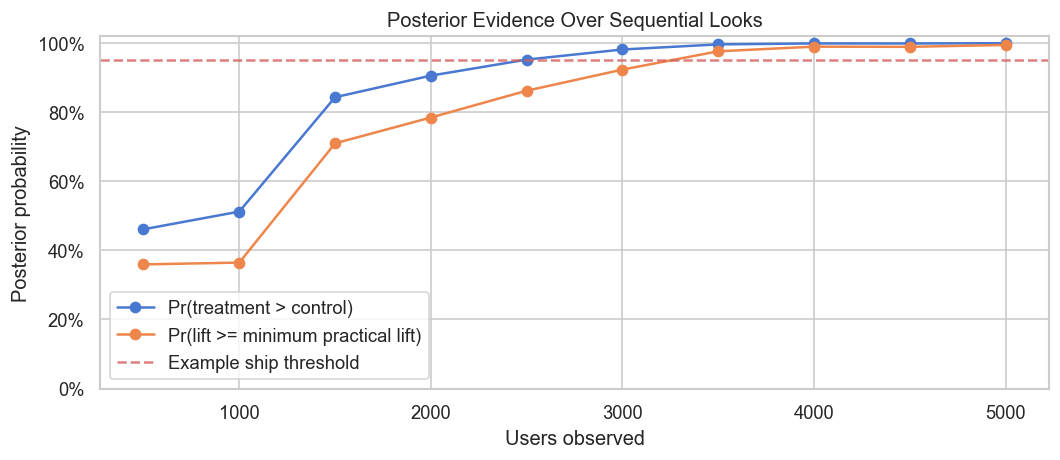

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    monitoring["users_seen"],
    monitoring["prob_treatment_better"],
    marker="o",
    label="Pr(treatment > control)",
)
ax.plot(
    monitoring["users_seen"],
    monitoring["prob_practical_lift"],
    marker="o",
    label="Pr(lift >= minimum practical lift)",
)
ax.axhline(0.95, color="C3", linestyle="--", alpha=0.8, label="Example ship threshold")
ax.set_title("Posterior Evidence Over Sequential Looks")
ax.set_xlabel("Users observed")
ax.set_ylabel("Posterior probability")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.02)
ax.legend()
plt.tight_layout()
plt.show()

## Part 5 - Bayesian Bootstrap for ARPU

Revenue per user is zero-inflated and skewed, so a Normal model is often a poor first pass. The Bayesian bootstrap estimates the posterior distribution of the mean without assuming a parametric revenue distribution.

Interpretation: each draw assigns random probability weights to the observed users, then computes the weighted ARPU. The difference between treatment and control weighted means is the posterior ARPU lift.

In [10]:
def bayesian_bootstrap_mean(
    values: np.ndarray,
    n_draws: int,
    rng: np.random.Generator,
    chunk_size: int = 2_000,
) -> np.ndarray:
    """Return Bayesian bootstrap draws of the sample mean."""
    values = np.asarray(values, dtype=float)
    draws = []
    for start in range(0, n_draws, chunk_size):
        current_chunk_size = min(chunk_size, n_draws - start)
        weights = rng.exponential(1.0, size=(current_chunk_size, len(values)))
        weights /= weights.sum(axis=1, keepdims=True)
        draws.append(weights @ values)
    return np.concatenate(draws)


control_revenue = experiment.loc[experiment["variant"].eq("control"), "first_30d_revenue"].to_numpy()
treatment_revenue = experiment.loc[experiment["variant"].eq("treatment"), "first_30d_revenue"].to_numpy()

control_arpu_draws = bayesian_bootstrap_mean(control_revenue, N_ARPU_DRAWS, rng)
treatment_arpu_draws = bayesian_bootstrap_mean(treatment_revenue, N_ARPU_DRAWS, rng)
arpu_lift_draws = treatment_arpu_draws - control_arpu_draws

print(f"Observed control ARPU:   ${control_revenue.mean():,.2f}")
print(f"Observed treatment ARPU: ${treatment_revenue.mean():,.2f}")
print(f"Posterior mean ARPU lift: ${arpu_lift_draws.mean():,.2f}")
print(
    "95% credible interval: "
    f"${np.quantile(arpu_lift_draws, 0.025):,.2f} to "
    f"${np.quantile(arpu_lift_draws, 0.975):,.2f}"
)
print(f"Pr(treatment ARPU > control ARPU): {(arpu_lift_draws > 0).mean():.2%}")
print(f"Expected ARPU loss if ship treatment: ${np.maximum(control_arpu_draws - treatment_arpu_draws, 0).mean():,.2f}")

Observed control ARPU:   $52.62
Observed treatment ARPU: $64.13
Posterior mean ARPU lift: $11.51
95% credible interval: $1.07 to $22.06
Pr(treatment ARPU > control ARPU): 98.48%
Expected ARPU loss if ship treatment: $0.03


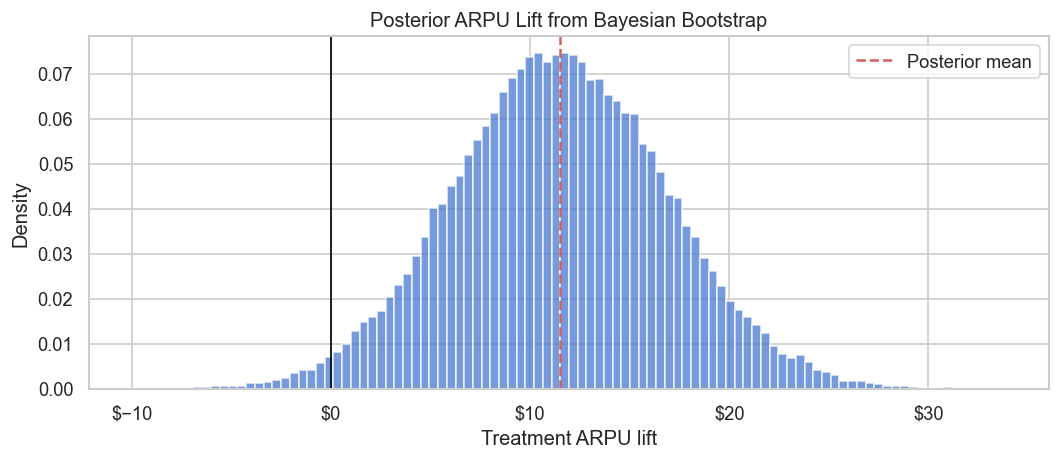

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(arpu_lift_draws, bins=100, density=True, alpha=0.75)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(arpu_lift_draws.mean(), color="C3", linestyle="--", label="Posterior mean")
ax.set_title("Posterior ARPU Lift from Bayesian Bootstrap")
ax.set_xlabel("Treatment ARPU lift")
ax.set_ylabel("Density")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways

- Bayesian A/B tests return decision probabilities directly, but the decision threshold still needs to be pre-registered.
- `Pr(treatment > control)` is not enough. Use a minimum practical lift and expected loss so you do not ship tiny wins that do not matter.
- Conjugate Beta-Binomial models are excellent for conversion metrics.
- Bayesian bootstrap is a useful default for skewed revenue metrics when you want a robust posterior over the mean.
- Sequential monitoring is cleanest when the stopping rule is based on posterior decision quantities agreed before launch.